# Prévision des Ventes — Modèles de Séries Temporelles
## Holt-Winters | SARIMA | SARIMAX | Prophet
## Données : Jan 2022 → Jan 2026 | Prévision : Fév 2026 → Jan 2027

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings
import json
import joblib

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement + Nettoyage

In [29]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year   AS year,
    d.Month  AS month,
    SUM(f.LinePrice) AS total_sales
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# Nettoyage mois incomplets
df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-02-01')
].reset_index(drop=True)

# Série temporelle indexée
ts = df.set_index('date')['total_sales']
ts.index.freq = 'MS'  # Monthly Start

print(f'✅ {len(ts)} mois chargés')
print(f'Période : {ts.index.min().strftime("%b %Y")} → {ts.index.max().strftime("%b %Y")}')
print(f'CA moyen mensuel : {ts.mean():,.2f} DT')
print(f'CA min           : {ts.min():,.2f} DT')
print(f'CA max           : {ts.max():,.2f} DT')
df.tail()

✅ 49 mois chargés
Période : Jan 2022 → Jan 2026
CA moyen mensuel : 1,157,029.65 DT
CA min           : 576,097.45 DT
CA max           : 1,644,113.02 DT


,year,month,total_sales,date
44,2025,9,"1,545,185.37",2025-09-01
45,2025,10,"1,635,378.39",2025-10-01
46,2025,11,"1,391,948.18",2025-11-01
47,2025,12,"1,623,158.26",2025-12-01
48,2026,1,"1,218,358.52",2026-01-01


## 2. Visualisation de la série temporelle

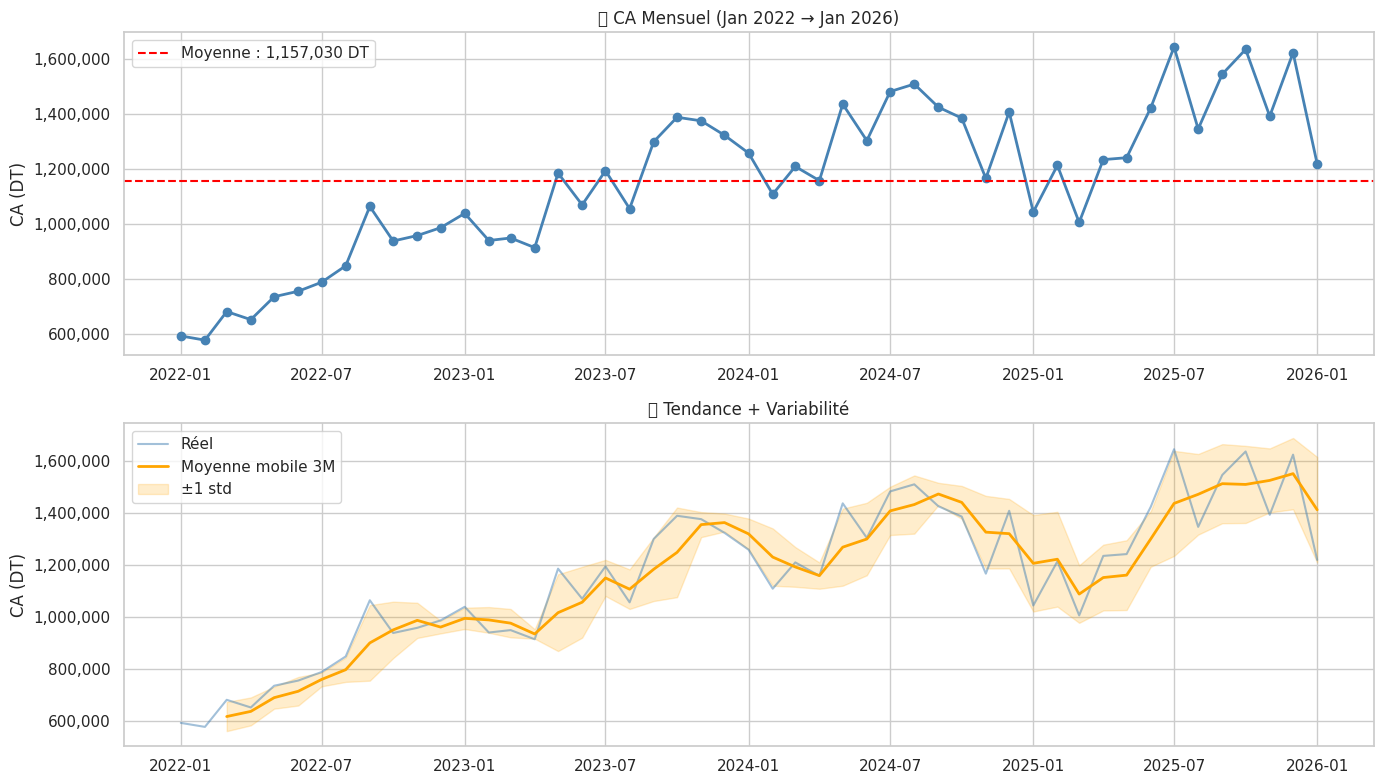

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Série brute
axes[0].plot(ts.index, ts.values, color='steelblue', marker='o', linewidth=2)
axes[0].axhline(ts.mean(), color='red', linestyle='--', label=f'Moyenne : {ts.mean():,.0f} DT')
axes[0].set_title('📈 CA Mensuel (Jan 2022 → Jan 2026)')
axes[0].set_ylabel('CA (DT)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()

# Décomposition visuelle — moyenne mobile
rolling_mean = ts.rolling(window=3).mean()
rolling_std  = ts.rolling(window=3).std()
axes[1].plot(ts.index, ts.values,           color='steelblue', alpha=0.5, label='Réel')
axes[1].plot(rolling_mean.index, rolling_mean.values, color='orange', linewidth=2, label='Moyenne mobile 3M')
axes[1].fill_between(ts.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    alpha=0.2, color='orange', label='±1 std')
axes[1].set_title('📊 Tendance + Variabilité')
axes[1].set_ylabel('CA (DT)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Test de stationnarité (ADF)

In [31]:
result = adfuller(ts)
print('=== Test ADF (Augmented Dickey-Fuller) ===')
print(f'Statistique ADF : {result[0]:.4f}')
print(f'p-value         : {result[1]:.4f}')
print(f'Valeurs critiques :')
for key, val in result[4].items():
    print(f'   {key} : {val:.4f}')

if result[1] < 0.05:
    print('\n✅ Série STATIONNAIRE (p < 0.05) → SARIMA sans différenciation')
else:
    print('\n⚠️  Série NON STATIONNAIRE (p > 0.05) → SARIMA avec d=1')

=== Test ADF (Augmented Dickey-Fuller) ===
Statistique ADF : -1.8989
p-value         : 0.3326
Valeurs critiques :
   1% : -3.6104
   5% : -2.9391
   10% : -2.6081

⚠️  Série NON STATIONNAIRE (p > 0.05) → SARIMA avec d=1


## 4. ACF / PACF — identifier les paramètres SARIMA

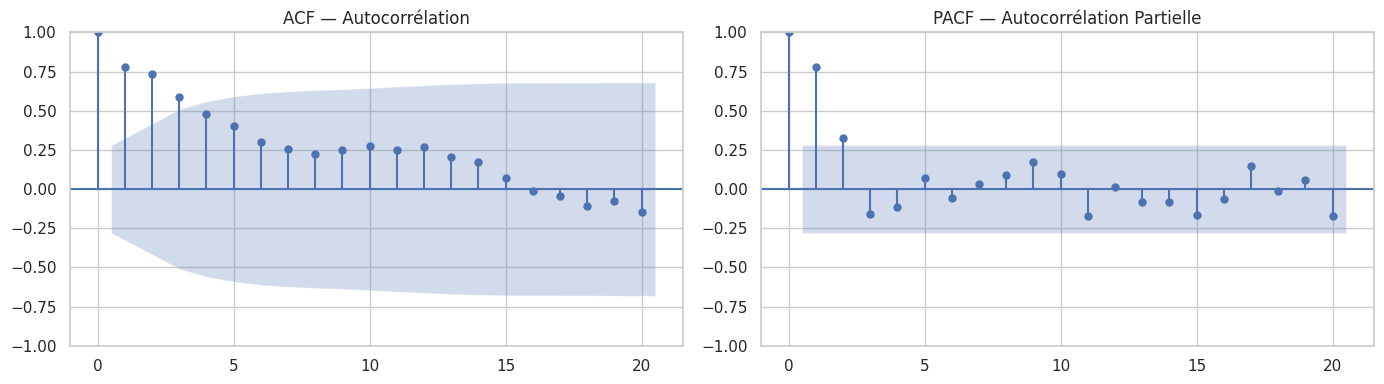

ACF  → pic au lag 12 = saisonnalité annuelle confirmée
PACF → indique l'ordre AR à utiliser


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts,  lags=20, ax=axes[0], title='ACF — Autocorrélation')
plot_pacf(ts, lags=20, ax=axes[1], title='PACF — Autocorrélation Partielle')
plt.tight_layout()
plt.show()
print('ACF  → pic au lag 12 = saisonnalité annuelle confirmée')
print('PACF → indique l\'ordre AR à utiliser')

## 5. Split Train / Test

Train : 43 mois (Jan 2022 → Jul 2025)
Test  : 6 mois (Aug 2025 → Jan 2026)


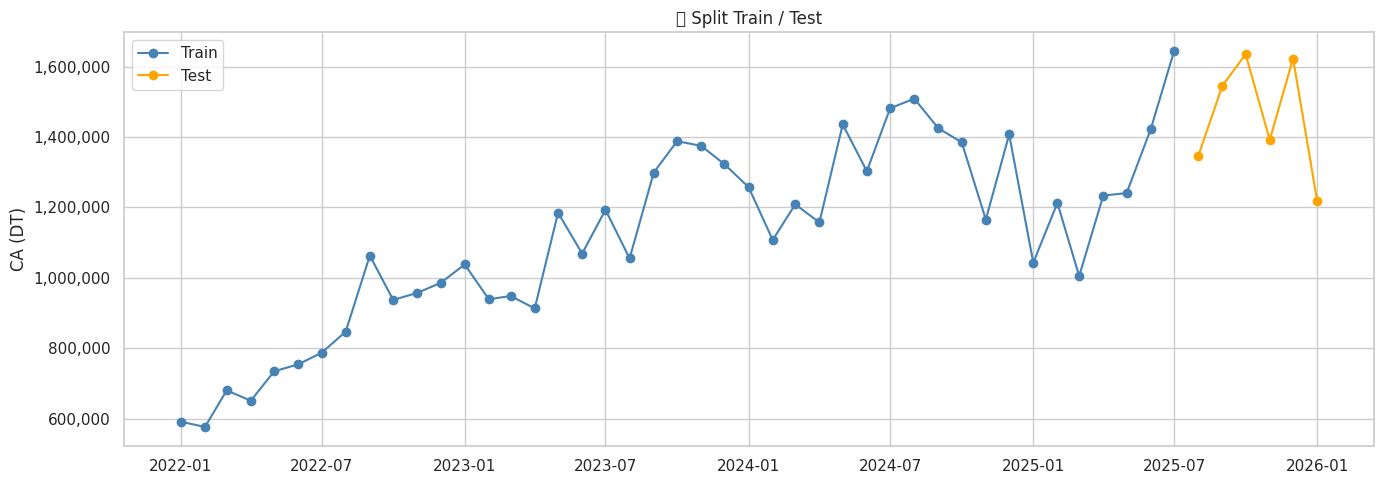

In [33]:
# Garder les 4 derniers mois pour le test
N_TEST    = 6
ts_train  = ts.iloc[:-N_TEST]
ts_test   = ts.iloc[-N_TEST:]

print(f'Train : {len(ts_train)} mois ({ts_train.index[0].strftime("%b %Y")} → {ts_train.index[-1].strftime("%b %Y")})')
print(f'Test  : {len(ts_test)} mois ({ts_test.index[0].strftime("%b %Y")} → {ts_test.index[-1].strftime("%b %Y")})')

fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values, color='steelblue', marker='o', label='Train')
ax.plot(ts_test.index,  ts_test.values,  color='orange',    marker='o', label='Test')
ax.set_title('📊 Split Train / Test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Fonction d'évaluation commune

In [34]:
def evaluate_ts(name, y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    bias  = np.mean(y_pred - y_true)
    return {
        'name': name, 'pred': y_pred,
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE': mape, 'SMAPE': smape, 'Biais': bias
    }

all_results = []
print('✅ Fonction evaluate_ts définie')

✅ Fonction evaluate_ts définie


In [35]:
# =========================================================
# BASELINE NAIVE
# =========================================================

print('='*50)
print('0️⃣ BASELINE NAIVE')
print('='*50)

naive_pred = np.repeat(ts_train.iloc[-1], N_TEST)

naive_res = evaluate_ts(
    'Naive Forecast',
    ts_test.values,
    naive_pred
)

all_results.append(naive_res)

print(f'MAE   : {naive_res["MAE"]:,.0f}')
print(f'RMSE  : {naive_res["RMSE"]:,.0f}')
print(f'MAPE  : {naive_res["MAPE"]:.2f}%')

0️⃣ BASELINE NAIVE
MAE   : 184,201
RMSE  : 239,569
MAPE  : 13.91%


In [36]:
print('='*50)
print('0️⃣ Holt Linear Trend')
print('='*50)

holt_model = ExponentialSmoothing(
    ts_train,
    trend='add',
    seasonal=None
).fit(optimized=True)

holt_pred = holt_model.forecast(N_TEST)

holt_res = evaluate_ts(
    'Holt Linear',
    ts_test.values,
    holt_pred.values
)

all_results.append(holt_res)

print(f'MAPE : {holt_res["MAPE"]:.2f}%')

0️⃣ Holt Linear Trend
MAPE : 14.75%


## 7. Modèle 1 — Holt-Winters (Triple Exponential Smoothing)

1️⃣  Holt-Winters
MAE  :      127,066 DT
RMSE :      168,298 DT
MAPE :         9.58 %
Biais:      123,701 DT


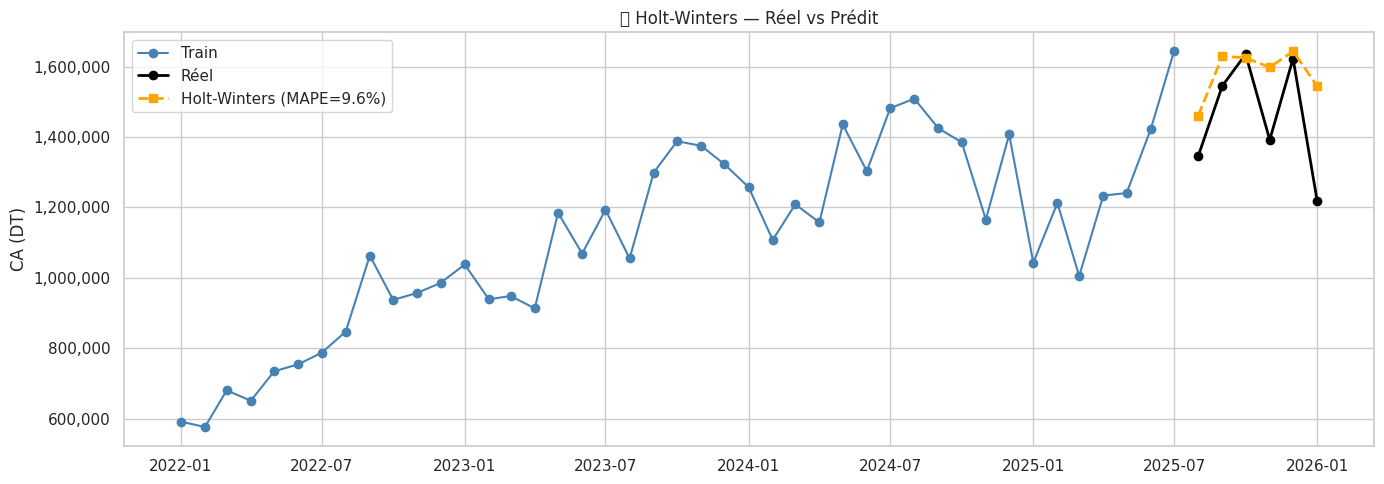

In [37]:
print('='*50)
print('1️⃣  Holt-Winters')
print('='*50)

hw_model = ExponentialSmoothing(
    ts_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_pred = hw_model.forecast(N_TEST)
hw_res  = evaluate_ts('Holt-Winters', ts_test.values, hw_pred.values)
all_results.append(hw_res)

print(f'MAE  : {hw_res["MAE"]:>12,.0f} DT')
print(f'RMSE : {hw_res["RMSE"]:>12,.0f} DT')
#print(f'R²   : {hw_res["R²"]:>12.4f}')
print(f'MAPE : {hw_res["MAPE"]:>12.2f} %')
print(f'Biais: {hw_res["Biais"]:>12,.0f} DT')

# Visualiser
fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values, color='steelblue', label='Train', marker='o')
ax.plot(ts_test.index,  ts_test.values,  color='black',     label='Réel',  marker='o', linewidth=2)
ax.plot(ts_test.index,  hw_pred.values,  color='orange',    label=f'Holt-Winters (MAPE={hw_res["MAPE"]:.1f}%)', marker='s', linestyle='--', linewidth=2)
ax.set_title('📈 Holt-Winters — Réel vs Prédit')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 8. Modèle 2 — Holt-Winters Multiplicatif

In [38]:
print('='*50)
print('2️⃣  Holt-Winters Multiplicatif')
print('='*50)

# Multiplicatif — meilleur si la saisonnalité croît avec le niveau
hw_mul_model = ExponentialSmoothing(
    ts_train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit(optimized=True)

hw_mul_pred = hw_mul_model.forecast(N_TEST)
hw_mul_res  = evaluate_ts('HW-Multiplicatif', ts_test.values, hw_mul_pred.values)
all_results.append(hw_mul_res)

print(f'MAE  : {hw_mul_res["MAE"]:>12,.0f} DT')
print(f'RMSE : {hw_mul_res["RMSE"]:>12,.0f} DT')
print(f'R²   : {hw_mul_res["R²"]:>12.4f}')
print(f'MAPE : {hw_mul_res["MAPE"]:>12.2f} %')
print(f'Biais: {hw_mul_res["Biais"]:>12,.0f} DT')

2️⃣  Holt-Winters Multiplicatif
MAE  :      146,166 DT
RMSE :      174,296 DT
R²   :      -0.2948
MAPE :        10.74 %
Biais:      146,166 DT


## 9. Modèle 3 — SARIMA

3️⃣  SARIMA(1,1,1)(1,1,1,12)
MAE  :      186,871 DT
RMSE :      201,511 DT
MAPE :        13.49 %
Biais:      186,871 DT


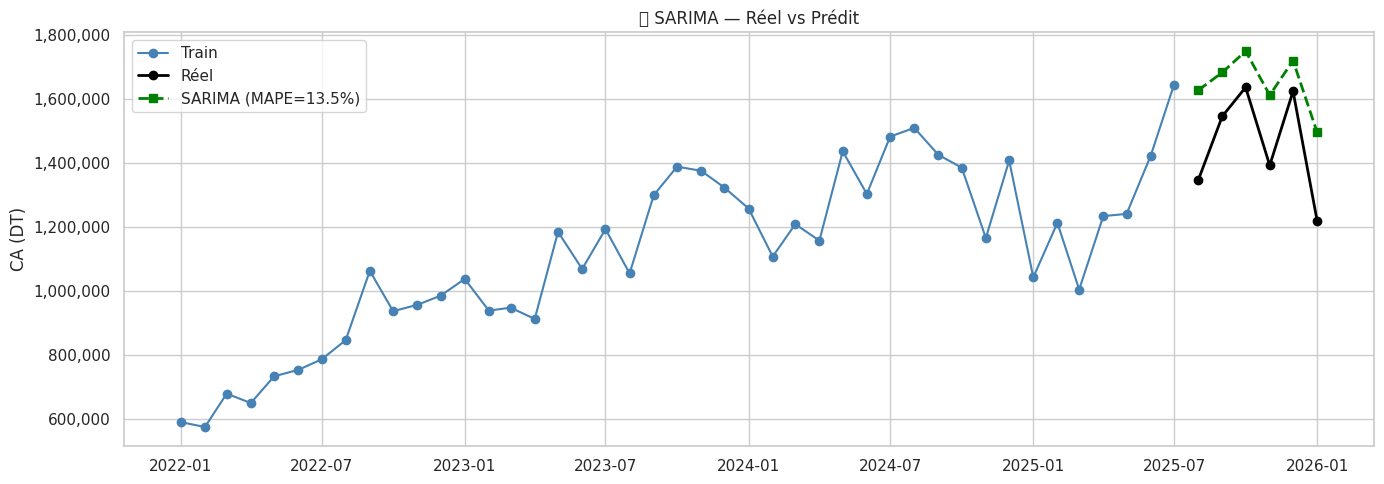

In [39]:
print('='*50)
print('3️⃣  SARIMA(1,1,1)(1,1,1,12)')
print('='*50)

sarima_model = SARIMAX(
    ts_train,
    order=(1, 1, 1),           # p, d, q
    seasonal_order=(1, 1, 1, 12),  # P, D, Q, s
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_pred = sarima_model.forecast(steps=N_TEST)
sarima_res  = evaluate_ts('SARIMA(1,1,1)', ts_test.values, sarima_pred.values)
all_results.append(sarima_res)

print(f'MAE  : {sarima_res["MAE"]:>12,.0f} DT')
print(f'RMSE : {sarima_res["RMSE"]:>12,.0f} DT')
print(f'MAPE : {sarima_res["MAPE"]:>12.2f} %')
print(f'Biais: {sarima_res["Biais"]:>12,.0f} DT')

fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values,  color='steelblue', label='Train', marker='o')
ax.plot(ts_test.index,  ts_test.values,   color='black',     label='Réel',  marker='o', linewidth=2)
ax.plot(ts_test.index,  sarima_pred.values, color='green',   label=f'SARIMA (MAPE={sarima_res["MAPE"]:.1f}%)', marker='s', linestyle='--', linewidth=2)
ax.set_title('📈 SARIMA — Réel vs Prédit')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 10. Modèle 4 — SARIMA auto (grid search sur les paramètres)

In [40]:
print('='*50)
print('4️⃣  SARIMA — Grid Search paramètres')
print('='*50)

import itertools

best_aic   = np.inf
best_order = None
best_model_sarima = None

p_values = [0,1]
d_values = [0,1]
q_values = [0,1]

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        m = SARIMAX(
            ts_train,
            order=(p, d, q),
            seasonal_order=(0,1,1,12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        if m.aic < best_aic:
            best_aic   = m.aic
            best_order = (p, d, q)
            best_model_sarima = m
    except:
        continue

print(f'✅ Meilleur ordre : {best_order} | AIC = {best_aic:.2f}')

sarima_auto_pred = best_model_sarima.forecast(steps=N_TEST)
sarima_auto_res  = evaluate_ts(f'SARIMA{best_order}', ts_test.values, sarima_auto_pred.values)
all_results.append(sarima_auto_res)

print(f'MAE  : {sarima_auto_res["MAE"]:>12,.0f} DT')
print(f'RMSE : {sarima_auto_res["RMSE"]:>12,.0f} DT')
print(f'R²   : {sarima_auto_res["R²"]:>12.4f}')
print(f'MAPE : {sarima_auto_res["MAPE"]:>12.2f} %')
print(f'Biais: {sarima_auto_res["Biais"]:>12,.0f} DT')

4️⃣  SARIMA — Grid Search paramètres
✅ Meilleur ordre : (1, 1, 1) | AIC = 434.68
MAE  :      149,407 DT
RMSE :      179,908 DT
R²   :      -0.3795
MAPE :        10.90 %
Biais:      149,407 DT


## 11. Comparaison de tous les modèles

Modèle                        MAE       RMSE       R²     MAPE    SMAPE        Biais
Naive Forecast            184,201    239,569  -1.4461   13.91%   12.39%      184,201
Holt Linear               194,904    258,328  -1.8442   14.75%   12.98%      194,904
Holt-Winters              127,066    168,298  -0.2072    9.58%    8.80%      123,701
HW-Multiplicatif          146,166    174,296  -0.2948   10.74%    9.93%      146,166
SARIMA(1,1,1)             186,871    201,511  -0.7307   13.49%   12.45%      186,871
SARIMA(1, 1, 1)           149,407    179,908  -0.3795   10.90%   10.08%      149,407

🏆 Meilleur modèle : Holt-Winters (MAPE = 9.58%)


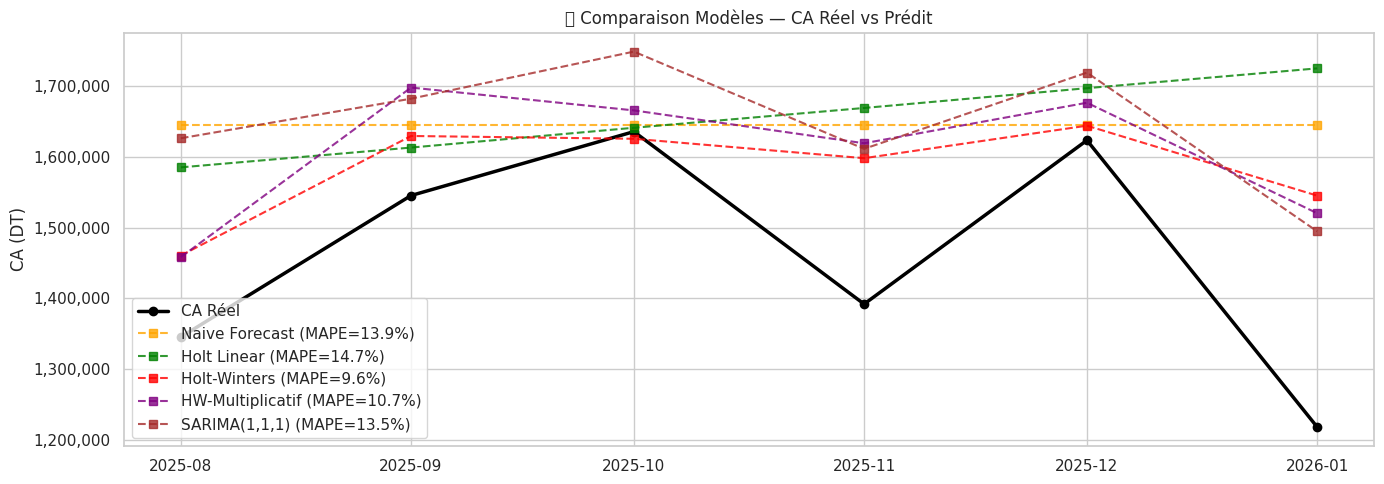

In [41]:
df_results = pd.DataFrame(all_results).set_index('name')

print('=' * 80)
print(f'{"Modèle":<22} {"MAE":>10} {"RMSE":>10} {"R²":>8} {"MAPE":>8} {"SMAPE":>8} {"Biais":>12}')
print('=' * 80)
for _, row in df_results.iterrows():
    print(f'{row.name:<22} {row["MAE"]:>10,.0f} {row["RMSE"]:>10,.0f} '
          f'{row["R²"]:>8.4f} {row["MAPE"]:>7.2f}% {row["SMAPE"]:>7.2f}% {row["Biais"]:>12,.0f}')
print('=' * 80)

best_name = df_results['MAPE'].idxmin()
print(f'\n🏆 Meilleur modèle : {best_name} (MAPE = {df_results.loc[best_name, "MAPE"]:.2f}%)')

# Graphe comparatif
fig, ax = plt.subplots()
ax.plot(ts_test.index, ts_test.values, color='black', marker='o', linewidth=2.5, label='CA Réel')
colors = ['orange', 'green', 'red', 'purple', 'brown']
for (name, row), color in zip(df_results.iterrows(), colors):
    ax.plot(ts_test.index, row['pred'],
            label=f'{name} (MAPE={row["MAPE"]:.1f}%)',
            marker='s', linestyle='--', color=color, alpha=0.8)
ax.set_title('📈 Comparaison Modèles — CA Réel vs Prédit')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 12. Prédiction des 12 prochains mois — meilleur modèle

In [42]:
print(f'Réentraînement de {best_name} sur toute la série ({len(ts)} mois)...')

if 'Holt-Winters' == best_name:
    final_model = ExponentialSmoothing(
        ts, trend='add', seasonal='add', seasonal_periods=12
    ).fit(optimized=True)
    forecast_12 = final_model.forecast(12)

elif 'HW-Multiplicatif' == best_name:
    final_model = ExponentialSmoothing(
        ts, trend='add', seasonal='mul', seasonal_periods=12
    ).fit(optimized=True)
    forecast_12 = final_model.forecast(12)

elif 'SARIMA(1,1,1)' == best_name:
    final_model = SARIMAX(
        ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    forecast_12 = final_model.forecast(steps=12)

else:  # SARIMA auto
    final_model = SARIMAX(
        ts, order=best_order, seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    forecast_12 = final_model.forecast(steps=12)

# Créer les dates futures
last_date   = ts.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12, freq='MS'
)
forecast_12.index = future_dates

print(f'\n✅ Prédictions ({best_name}) :')
for date, val in forecast_12.items():
    print(f'  {date.strftime("%b %Y")} → {val:>15,.2f} DT')

print(f'\nCA prévisionnel total : {forecast_12.sum():,.2f} DT')

Réentraînement de Holt-Winters sur toute la série (49 mois)...

✅ Prédictions (Holt-Winters) :
  Feb 2026 →    1,315,510.53 DT
  Mar 2026 →    1,281,173.82 DT
  Apr 2026 →    1,323,940.21 DT
  May 2026 →    1,505,633.31 DT
  Jun 2026 →    1,480,089.38 DT
  Jul 2026 →    1,554,372.46 DT
  Aug 2026 →    1,533,953.51 DT
  Sep 2026 →    1,657,607.50 DT
  Oct 2026 →    1,631,248.08 DT
  Nov 2026 →    1,556,964.96 DT
  Dec 2026 →    1,624,998.36 DT
  Jan 2027 →    1,489,839.04 DT

CA prévisionnel total : 17,955,331.17 DT


## 13. Visualisation finale — Réel + Prédit sur un seul graphe

In [43]:
import plotly.graph_objects as go

fig = go.Figure()

# CA réel
fig.add_trace(go.Scatter(
    x=ts.index, y=ts.values,
    name='CA Réel',
    mode='lines+markers',
    line=dict(color='steelblue', width=2),
    marker=dict(size=5)
))

# CA prédit
fig.add_trace(go.Scatter(
    x=forecast_12.index, y=forecast_12.values,
    name=f'CA Prédit ({best_name})',
    mode='lines+markers',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))

# Ligne de coupure
fig.add_vline(
    x=last_date.timestamp() * 1000,
    line_dash='dot', line_color='red',
    annotation_text=f'{last_date.strftime("%b %Y")} — Fin données réelles'
)

fig.update_layout(
    title=f'📈 CA Réel (Jan 2022 → Jan 2026) + Prédit (Fév 2026 → Jan 2027) — {best_name}',
    xaxis_title='Mois',
    yaxis_title='CA (DT)',
    hovermode='x unified',
    height=500
)
fig.show()

## 14. CA annuel prévu

📋 PRÉVISION CA ANNUEL
CA réel 2024       :   15,843,689.48 DT
CA réel 2025       :   16,342,751.14 DT
CA prévu 2026-2027 :   17,955,331.17 DT
Croissance prévue  :            9.87 %
Modèle             : Holt-Winters
MAPE test          : 9.58%


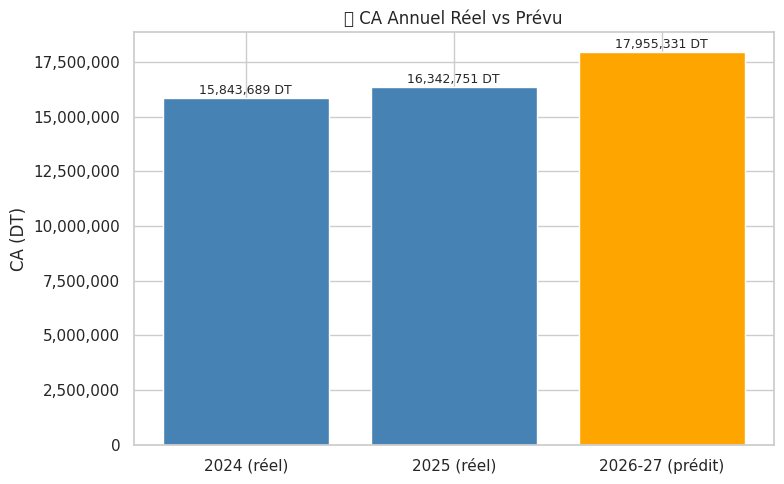

In [44]:
ca_prevu  = forecast_12.sum()
ca_2025   = ts[ts.index.year == 2025].sum()
ca_2024   = ts[ts.index.year == 2024].sum()
croissance = (ca_prevu - ca_2025) / ca_2025 * 100

print('=' * 55)
print('📋 PRÉVISION CA ANNUEL')
print('=' * 55)
print(f'CA réel 2024       : {ca_2024:>15,.2f} DT')
print(f'CA réel 2025       : {ca_2025:>15,.2f} DT')
print(f'CA prévu 2026-2027 : {ca_prevu:>15,.2f} DT')
print(f'Croissance prévue  : {croissance:>15.2f} %')
print(f'Modèle             : {best_name}')
print(f'MAPE test          : {df_results.loc[best_name, "MAPE"]:.2f}%')
print('=' * 55)

# Graphe annuel
years_data = pd.DataFrame([
    {'Année': '2024 (réel)', 'CA': ca_2024},
    {'Année': '2025 (réel)', 'CA': ca_2025},
    {'Année': '2026-27 (prédit)', 'CA': ca_prevu},
])

fig, ax = plt.subplots(figsize=(8, 5))
colors  = ['steelblue', 'steelblue', 'orange']
ax.bar(years_data['Année'], years_data['CA'], color=colors)
for i, (_, r) in enumerate(years_data.iterrows()):
    ax.text(i, r['CA'] + years_data['CA'].max() * 0.01,
            f"{r['CA']:,.0f} DT", ha='center', fontsize=9)
ax.set_title('📊 CA Annuel Réel vs Prévu')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 15. Écriture dans ClickHouse Gold

In [45]:
df_pred = pd.DataFrame({
    'date':            forecast_12.index,
    'year':            forecast_12.index.year,
    'month':           forecast_12.index.month,
    'predicted_sales': forecast_12.values,
    'is_prediction':   1
})

client2 = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

client2.command("""
    CREATE TABLE IF NOT EXISTS gold.ml_predictions (
        date             Date,
        year             Int32,
        month            Int32,
        predicted_sales  Float64,
        is_prediction    Int8
    )
    ENGINE = MergeTree()
    ORDER BY date
""")

client2.command('TRUNCATE TABLE gold.ml_predictions')
client2.insert_df('gold.ml_predictions', df_pred)

check = client2.query_df('SELECT * FROM gold.ml_predictions ORDER BY date')
print(f'✅ {len(check)} prédictions écrites dans ClickHouse Gold')
print('   Table : gold.ml_predictions\n')
print(check.to_string(index=False))

ProgrammingError: Unrecognized column 'date' in table gold.ml_predictions